# Proyecto Redes Neuronales Convolucionales 
Elaborado por: **Daniela Ivon Zabala Donato**
> 20251695011

> Instalar dependencias para el entrenamiento del modelo

In [ ]:
!pip install ultralytics opencv-python pillow pyyaml

> Configuración general de rutas e imports de librerías

In [ ]:
import os
import shutil
from pathlib import Path
import yaml
from PIL import Image
import random

from ultralytics import YOLO
import cv2

# ==================== CONFIGURACIÓN ====================

BASE_PATH = r"K:\imagenes_salon"
OUTPUT_PATH = r"K:\resultados_yolo"
TRAIN_SPLIT = 0.8  # 80% entrenamiento, 20% validación

# Clases a entrenar y detectar
CLASSES = ['cpu', 'mesa', 'mouse', 'pantalla', 'silla', 'teclado']

if not Path(BASE_PATH).exists():
    raise FileNotFoundError(f"❌ Error: No existe el directorio {BASE_PATH}")

> Función para preparar dataset

In [4]:
# ==================== PASO 1: PREPARAR DATASET YOLO ====================

def prepare_yolo_dataset():
    print("📁 Preparando dataset en formato YOLO...")
    
    # Crear estructura de carpetas
    for split in ['train', 'val']:
        for folder in ['images', 'labels']:
            Path(f"{OUTPUT_PATH}/{split}/{folder}").mkdir(parents=True, exist_ok=True)
    
    # Procesar cada clase
    all_images = []
    for class_name in CLASSES:
        class_path = Path(BASE_PATH) / class_name
        if not class_path.exists():
            print(f"⚠️  Advertencia: No existe carpeta {class_path}")
            continue
        
        images = list(class_path.glob("*.jpg")) + list(class_path.glob("*.png"))
        class_id = CLASSES.index(class_name)
        
        for img_path in images:
            all_images.append((img_path, class_id, class_name))
    
    # Mezclar y dividir
    random.shuffle(all_images)
    split_idx = int(len(all_images) * TRAIN_SPLIT)
    train_data = all_images[:split_idx]
    val_data = all_images[split_idx:]
    
    print(f"📊 Total imágenes: {len(all_images)}")
    print(f"   - Entrenamiento: {len(train_data)}")
    print(f"   - Validación: {len(val_data)}")
    
    # Copiar imágenes y crear anotaciones
    for split_name, data in [('train', train_data), ('val', val_data)]:
        for idx, (img_path, class_id, class_name) in enumerate(data):
            # Copiar imagen
            new_img_name = f"{class_name}_{idx}{img_path.suffix}"
            dest_img = Path(OUTPUT_PATH) / split_name / 'images' / new_img_name
            shutil.copy(img_path, dest_img)
            
            # Crear anotación 
            img = Image.open(img_path)
            
            # YOLO formato: clase x_center y_center width height (normalizado)
            annotation = f"{class_id} 0.5 0.5 0.9 0.9\n"
            
            label_path = Path(OUTPUT_PATH) / split_name / 'labels' / f"{class_name}_{idx}.txt"
            with open(label_path, 'w') as f:
                f.write(annotation)
    
    print("✅ Dataset preparado\n")


In [6]:
prepare_yolo_dataset()

📁 Preparando dataset en formato YOLO...
📊 Total imágenes: 1583
   - Entrenamiento: 1266
   - Validación: 317
✅ Dataset preparado



> Función para crear el YAML

In [7]:
# ==================== PASO 2: CREAR ARCHIVO DE CONFIGURACIÓN ====================

def create_yaml_config():
    """Crea el archivo data.yaml necesario para YOLO"""
    config = {
        'path': OUTPUT_PATH,
        'train': 'train/images',
        'val': 'val/images',
        'nc': len(CLASSES),  # número de clases
        'names': CLASSES
    }
    
    yaml_path = Path(OUTPUT_PATH) / 'data.yaml'
    with open(yaml_path, 'w') as f:
        yaml.dump(config, f, default_flow_style=False)
    
    print(f"✅ Configuración guardada en {yaml_path}\n")
    return yaml_path


In [8]:
yaml_path = create_yaml_config()

✅ Configuración guardada en K:\resultados_yolo\data.yaml



> Función para entrenar el modelo

In [ ]:
# ==================== PASO 3: ENTRENAR MODELO ====================

def train_model(yaml_path):
    """
    Entrena YOLOv8n (nano - versión más ligera)
    Otras opciones: yolov8s.pt (small), yolov8m.pt (medium)
    """
    print("🚀 Iniciando entrenamiento...")
    print("📦 Modelo: YOLOv8n (nano - ligero y rápido)\n")
    
    # Cargar modelo pre-entrenado
    model = YOLO('yolov8n.pt')  # Descarga automáticamente si no existe
    
    # Entrenar
    results = model.train(
        data=str(yaml_path),
        epochs=10,
        imgsz=640,
        batch=16,
        patience=20,
        save=True,
        device='cpu',   
        project=OUTPUT_PATH,
        name='salon_detector',
        exist_ok=True,
        
        # Aumentos de datos
        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.4,
        degrees=10,
        translate=0.1,
        scale=0.5,
        flipud=0.5,
        fliplr=0.5,
        mosaic=1.0
    )
    
    print("\n✅ Entrenamiento completado")
    print(f"📁 Modelo guardado en: {OUTPUT_PATH}/salon_detector/weights/best.pt")
    
    return model


In [15]:
model = train_model(yaml_path)

🚀 Iniciando entrenamiento...
📦 Modelo: YOLOv8n (nano - ligero y rápido)

New https://pypi.org/project/ultralytics/8.3.228 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.227  Python-3.13.3 torch-2.9.0+cpu CPU (AMD Ryzen 5 5500H with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=K:\resultados_yolo\data.yaml, degrees=10, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, moment

In [10]:
best_model_path = Path(OUTPUT_PATH) / 'salon_detector' / 'weights' / 'best.pt'
print(f"📁 Ruta del mejor modelo: {best_model_path}")

📁 Ruta del mejor modelo: K:\resultados_yolo\salon_detector\weights\best.pt


> Función para exportar el modelo

In [14]:
# ==================== PASO 5: EXPORTAR ====================

def export_for_web(model_path):
    """Exporta el modelo a onnx"""
    print("\n📦 Exportando modelo...")
    
    model = YOLO(model_path)
    
    # Exportar a .onnx
    model.export(format='onnx', imgsz=640)
    
    print("✅ Modelo exportado a .onnx")


In [15]:
# ==================== EXPORTAR MODELO PARA WEB ====================
export_for_web(str(best_model_path))

print("\n" + "=" * 60)
print("✅ PROCESO COMPLETADO")
print("=" * 60)
print(f"\n📁 Archivos generados en: {OUTPUT_PATH}")



📦 Exportando modelo...
Ultralytics 8.3.227  Python-3.13.3 torch-2.9.0+cpu CPU (AMD Ryzen 5 5500H with Radeon Graphics)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from 'C:\Users\danie\Downloads\yolo_dataset\salon_detector\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 10, 8400) (5.9 MB)

ONNX: starting export with onnx 1.19.1 opset 22...
ONNX: slimming with onnxslim 0.1.74...
ONNX: export success  1.0s, saved as 'C:\Users\danie\Downloads\yolo_dataset\salon_detector\weights\best.onnx' (11.7 MB)

Export complete (1.3s)
Results saved to C:\Users\danie\Downloads\yolo_dataset\salon_detector\weights
Predict:         yolo predict task=detect model=C:\Users\danie\Downloads\yolo_dataset\salon_detector\weights\best.onnx imgsz=640  
Validate:        yolo val task=detect model=C:\Users\danie\Downloads\yolo_dataset\salon_detector\weights\best.onnx imgsz=640 data=C:\Users\danie\Downloads\yolo_dataset\data.yaml  

# Información asociada al entrenamiento

> Precisiones alcanzadas durante el entrenamiento y validación sobre los conjuntos de 80% de train y 20% de val

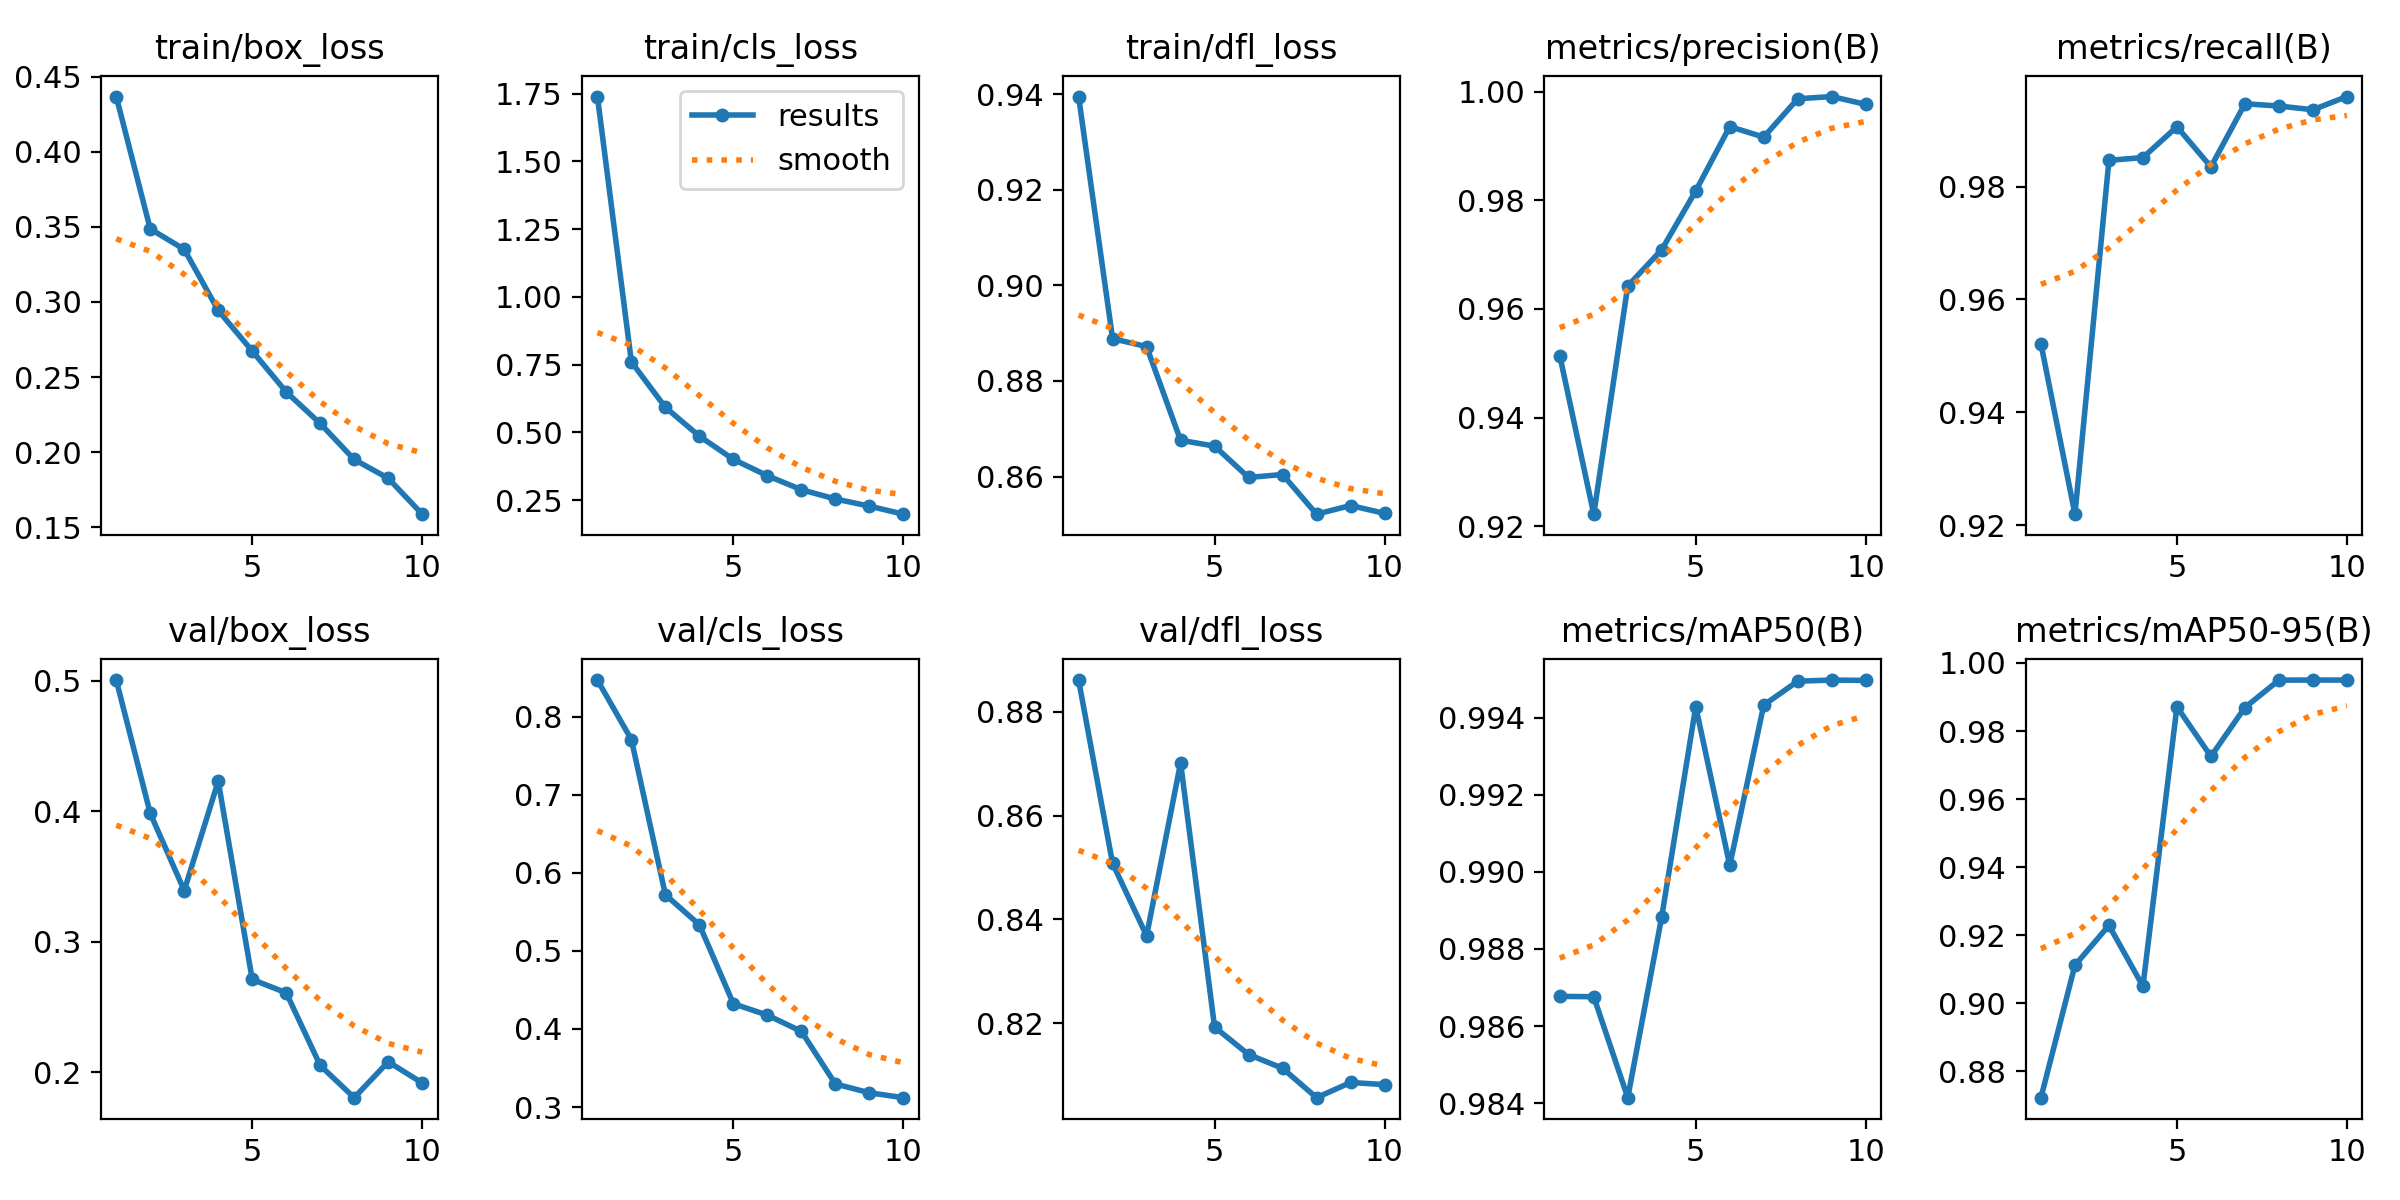

> Matriz de confusión asociada en la predicción

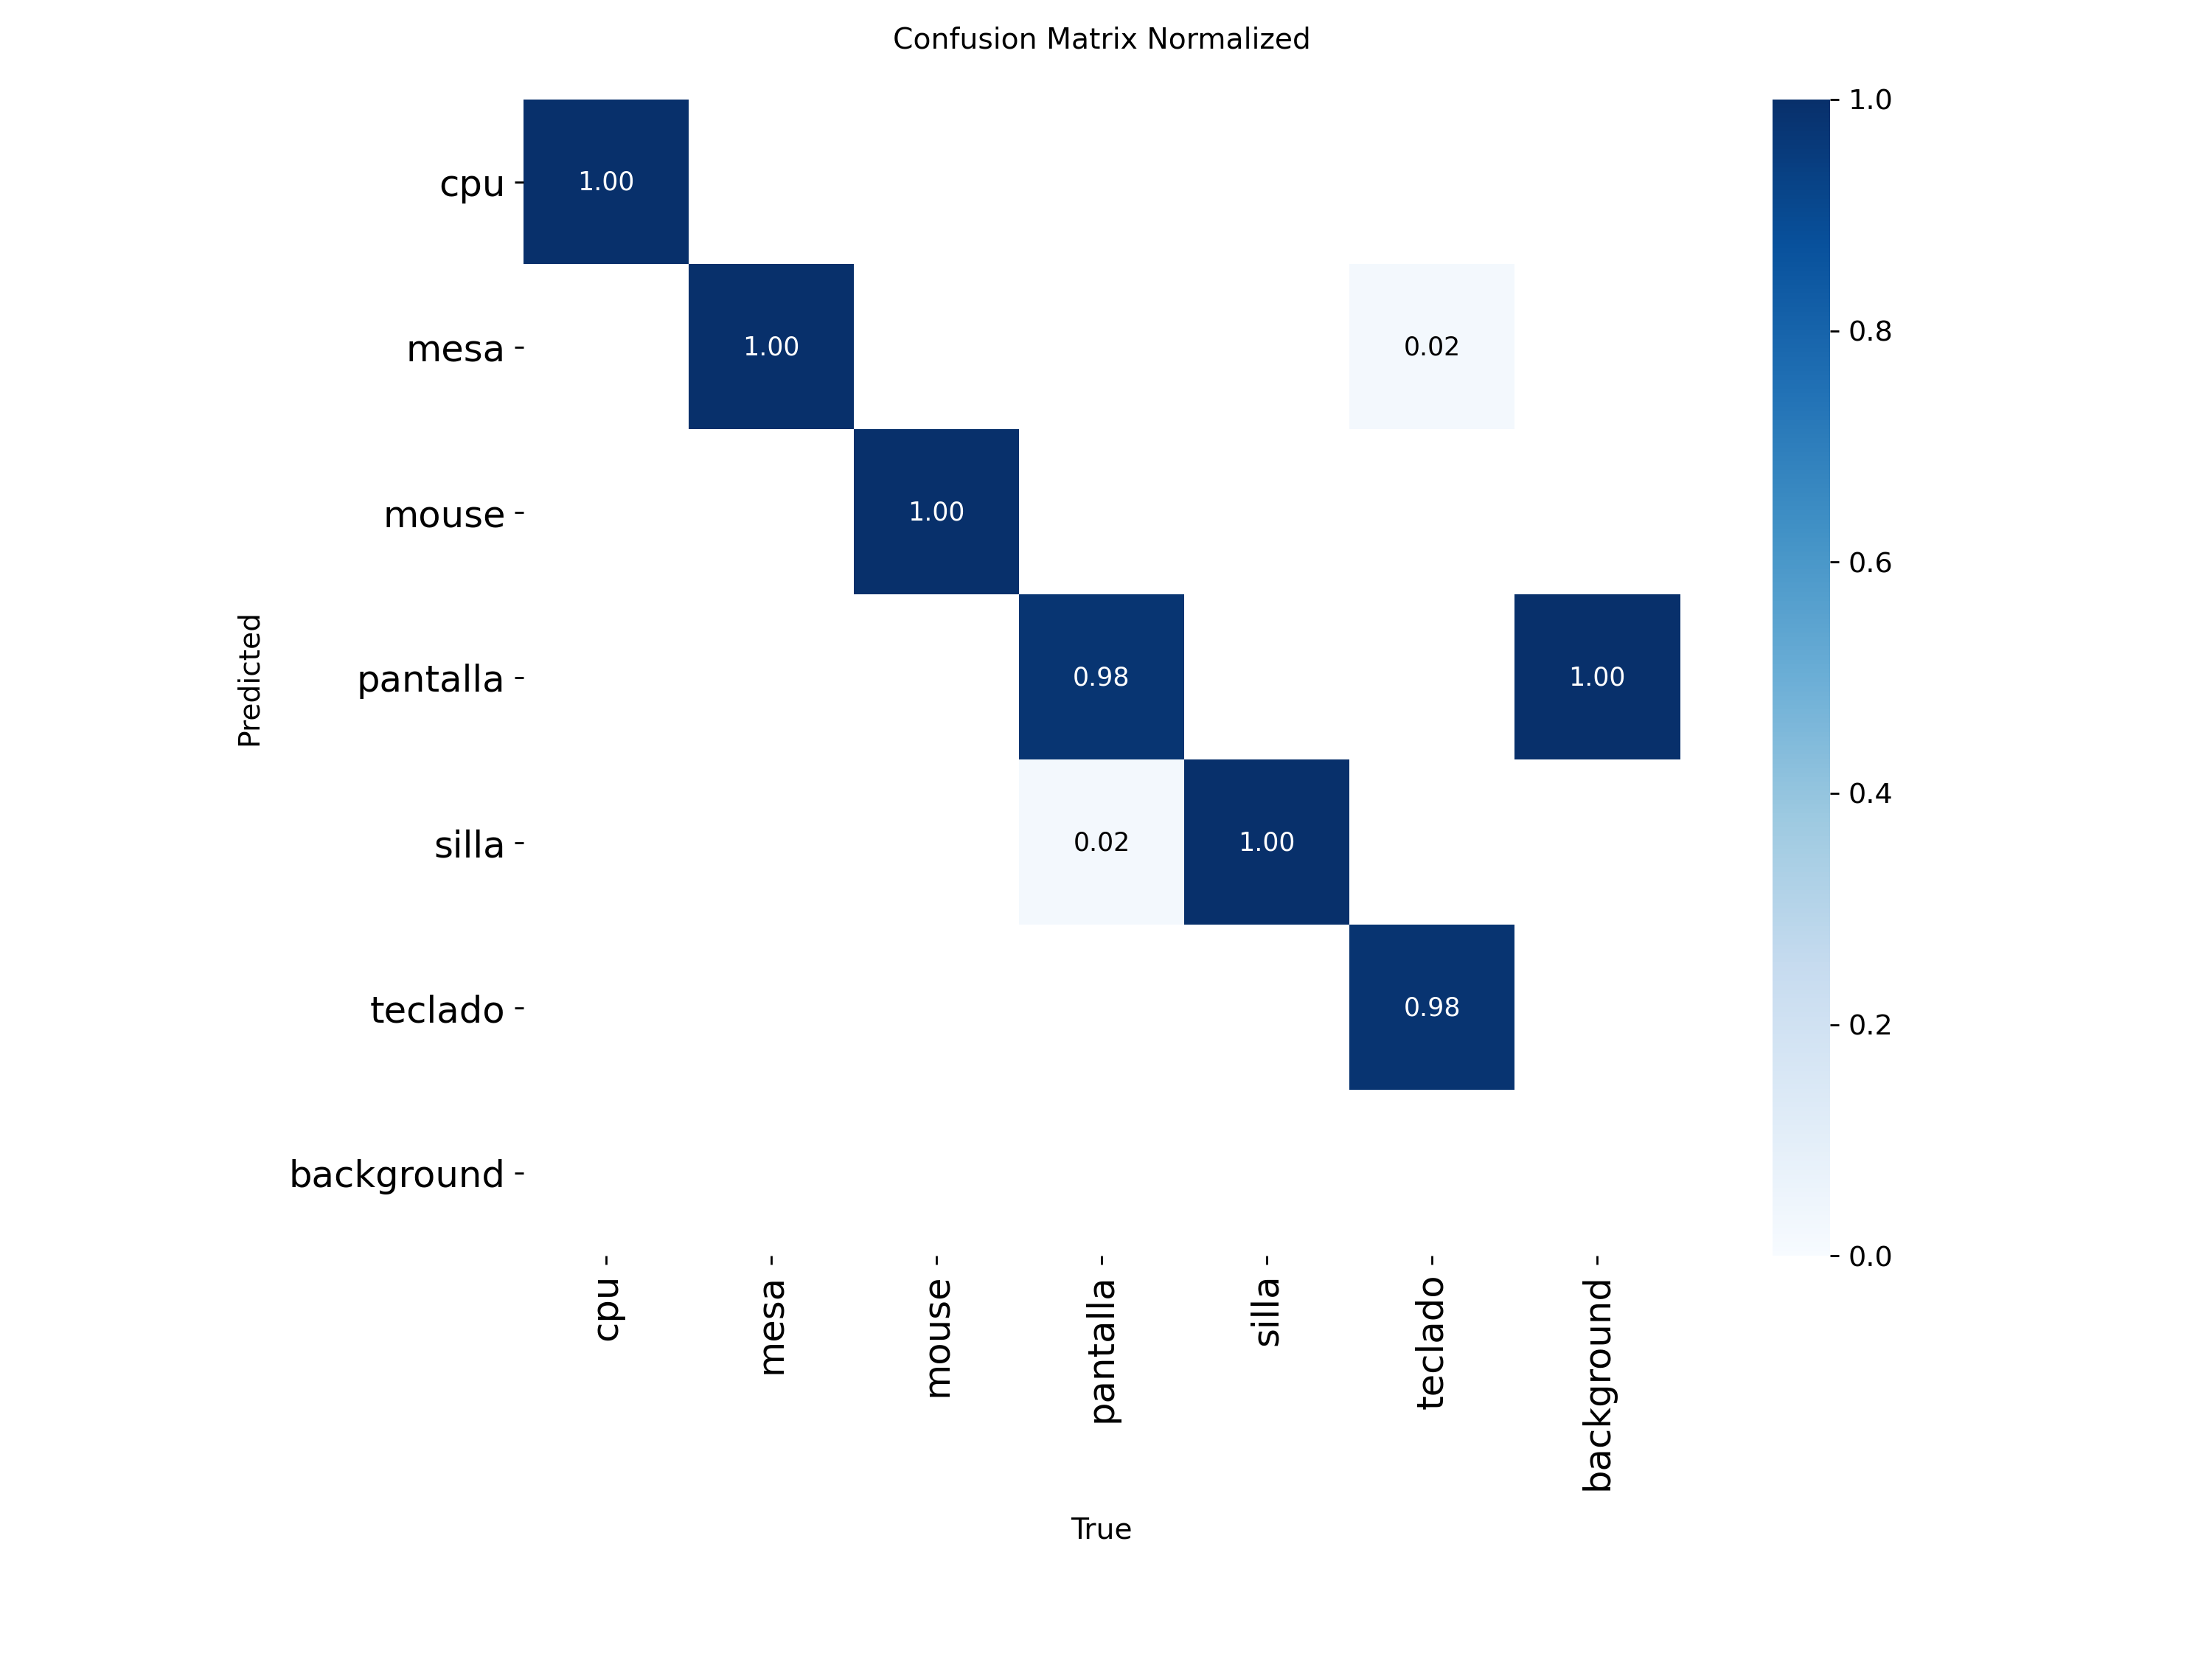

> Algunas de las etiquetas asociadas durante el entrenamiento

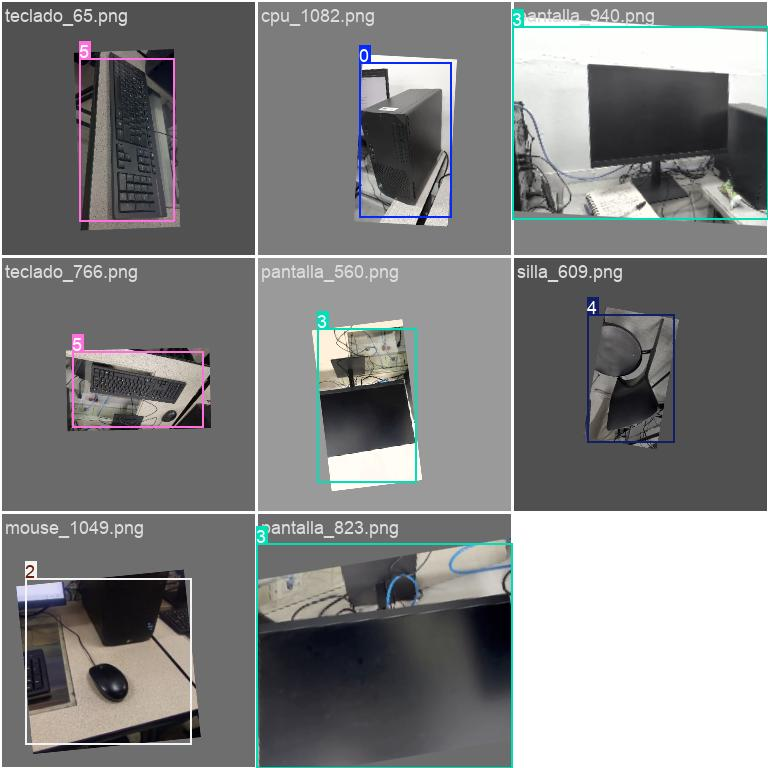

> Desempeño gráfico de la predicción sobre el conjunto de validación

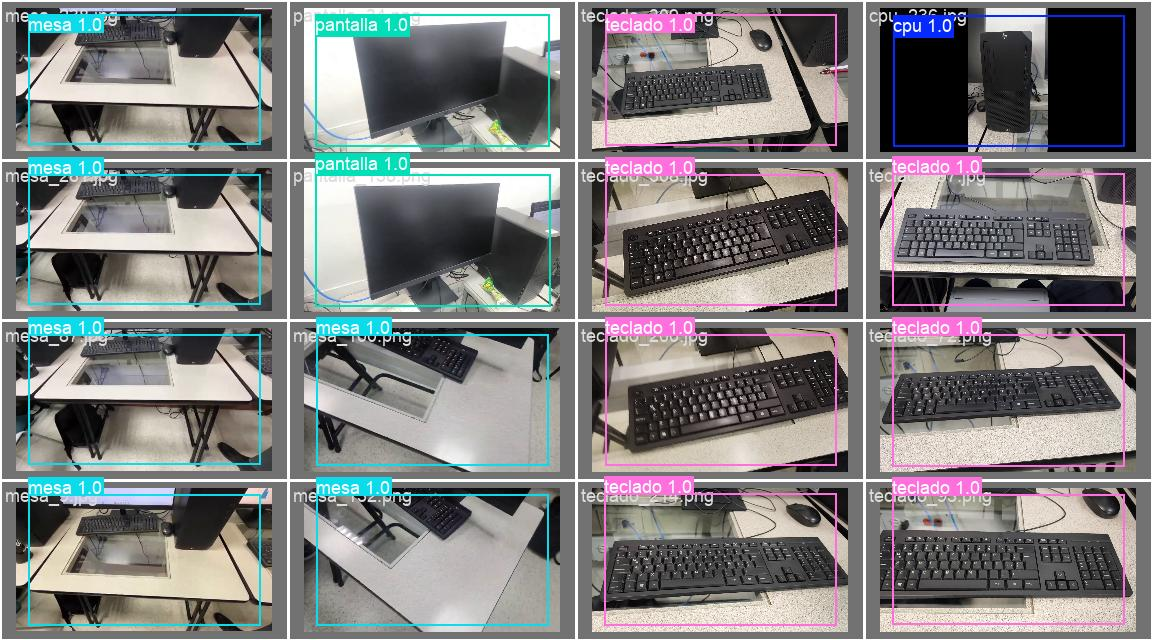